In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append(os.path.abspath("../src"))
from utils import (plot_execution_times, measure_algorithm_time, plot_comprehensive_barchart_grid, plot_danger_zone_heatmap,  load_data_from_folder,
    plot_algorithm_speedup_grid, plot_multiple_baselines)
import json

# Cấu hình tham số đồ thị
plt.rcParams['figure.figsize'] = (14, 10)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
sizes = [100, 1000, 10000, 100000]
datasets = ['random', 'nearly_sorted', 'many_duplicates', 'reverse_sorted']

dir_path = "../results"

with open(f"{dir_path}/selection_sort.json", "r") as f:
    res_selection = json.load(f)

with open(f"{dir_path}/insertion_sort.json", "r") as f:
    res_insertion = json.load(f)

with open(f"{dir_path}/merge_sort.json", "r") as f:
    res_merge = json.load(f)

with open(f"{dir_path}/counting_sort.json", "r") as f:
    res_counting = json.load(f)

In [3]:
all_algo_results = {
    "Selection Sort O(n^2)": res_selection,
    "Insertion Sort O(n^2)": res_insertion,
    "Merge Sort O(n log n)": res_merge,
    "Counting Sort O(n)": res_counting
}

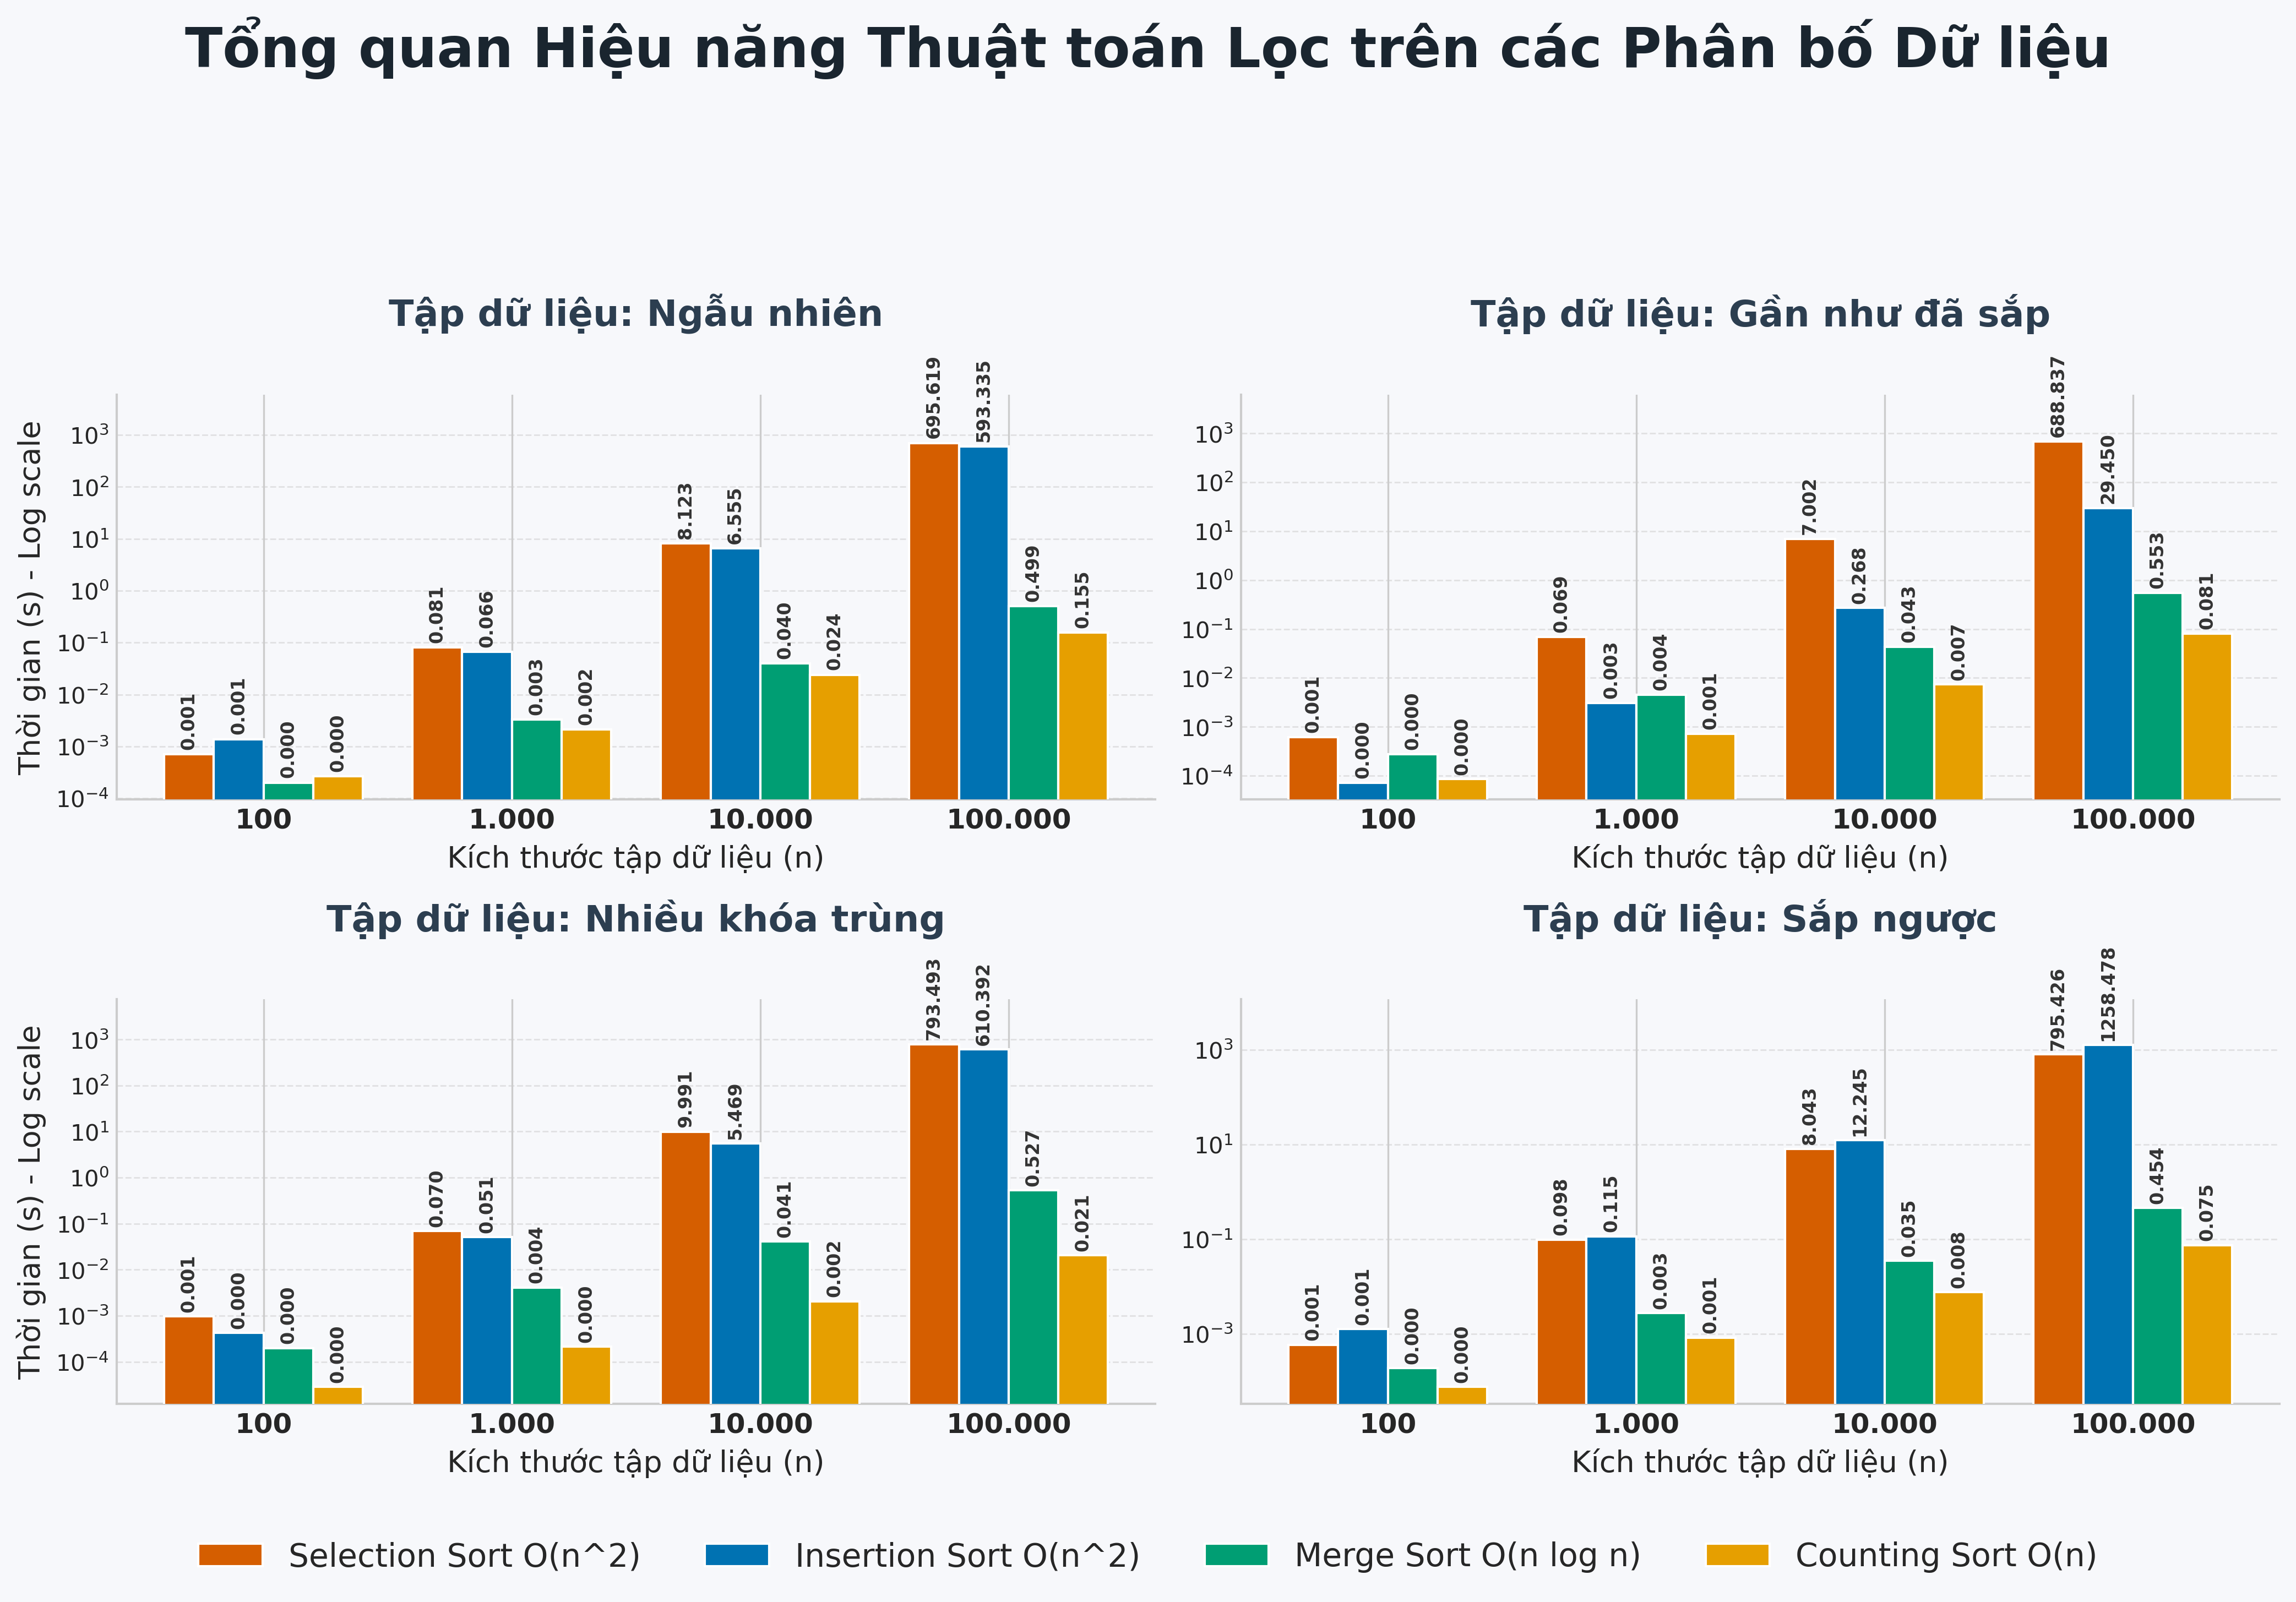

In [4]:
plot_comprehensive_barchart_grid(
    all_results=all_algo_results,
    sizes=sizes,
    datasets=datasets,
    title="Tổng quan Hiệu năng Thuật toán Lọc trên các Phân bố Dữ liệu"
)

## Đánh giá tổng quan hiệu năng qua Biểu đồ Cột nhóm
Biểu đồ cột nhóm kết hợp trục tung logarit cho thấy sự phân hóa tốc độ rõ rệt giữa các lớp thuật toán, đặc biệt bộc lộ ở kích thước mảng lớn nhất n = 100.000:
- **Nhóm O(n²) (Selection Sort và Insertion Sort):** Bộc lộ rõ hạn chế về mặt tốc độ. Selection Sort duy trì thời gian thực thi chậm một cách đồng đều trên mọi phân bố, dao động từ 688.837 giây đến 795.426 giây. Ngược lại, Insertion Sort thể hiện tính nhạy cảm cao với hình thái dữ liệu: tối ưu tốt trên mảng gần như đã sắp (29.450 giây) nhưng suy biến nghiêm trọng ở trường hợp xấu nhất là mảng sắp ngược (1258.478 giây).
  
- **Nhóm O(n log n) (Merge Sort):** Chứng minh tính ổn định tuyệt đối của chiến lược chia để trị. Thời gian thực thi gần như không bị ảnh hưởng bởi tính thứ tự ban đầu của dữ liệu, luôn duy trì đồng đều trong biên độ hẹp từ 0.454 giây đến 0.553 giây.
  
- **Nhóm O(n) (Counting Sort):** Khẳng định ưu thế tốc độ vượt trội nhất trong toàn bộ thử nghiệm. Thuật toán luôn hoàn thành nhanh nhất trên mọi phân bố và đạt mức tối ưu tuyệt đối tại tập dữ liệu nhiều khóa trùng với thời gian thực thi chỉ 0.021 giây.

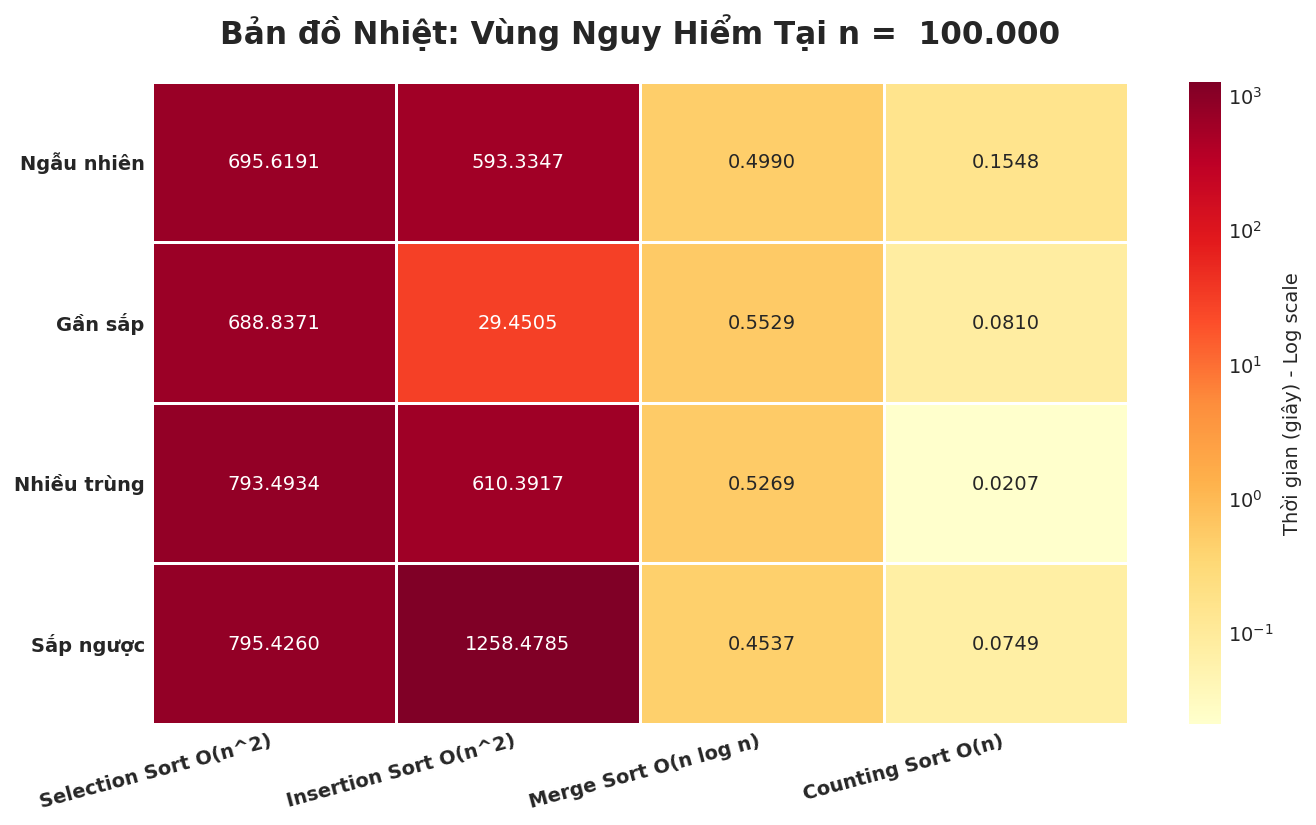

In [5]:
plot_danger_zone_heatmap(all_algo_results, 3, sizes, datasets)

## Đánh giá mức độ rủi ro hiệu năng qua Bản đồ Nhiệt
Bản đồ nhiệt ứng dụng thang màu logarit phân định rõ hai vùng rủi ro hiệu năng đối lập tại tải trọng tối đa n = 100.000:
- **Vùng rủi ro thấp (Nhóm thuật toán O(n) và O(n log n)):** Nửa bên phải bản đồ phủ các dải màu sáng, đại diện cho độ tin cậy cao. Counting Sort cho thấy tốc độ xử lý nhanh nhất, đạt mức tối ưu 0.0207 giây tại mảng nhiều khóa trùng. Merge Sort duy trì tính ổn định hoàn hảo, thời gian thực thi biến thiên trong biên độ rất hẹp từ 0.4537 giây đến 0.5529 giây trên mọi phân bố dữ liệu, chứng tỏ thuật toán miễn nhiễm với sự xáo trộn của cấu trúc mảng đầu vào.

- **Vùng cảnh báo rủi ro (Nhóm thuật toán O(n²)):** Nửa bên trái bản đồ bị chi phối bởi dải màu đỏ sẫm, cảnh báo tình trạng quá tải. Selection Sort bộc lộ sự chậm chạp đồng đều ở mọi kịch bản, dao động từ 688.8371 giây đến 795.4260 giây. Đáng chú ý nhất, Insertion Sort phản ánh sự suy biến cực đoan; mặc dù có thể xử lý mảng gần như đã sắp trong 29.4505 giây, thuật toán này lại rơi vào tình trạng quá tải nghiêm trọng nhất ở mảng sắp ngược với thời gian kỷ lục lên tới 1258.4785 giây.

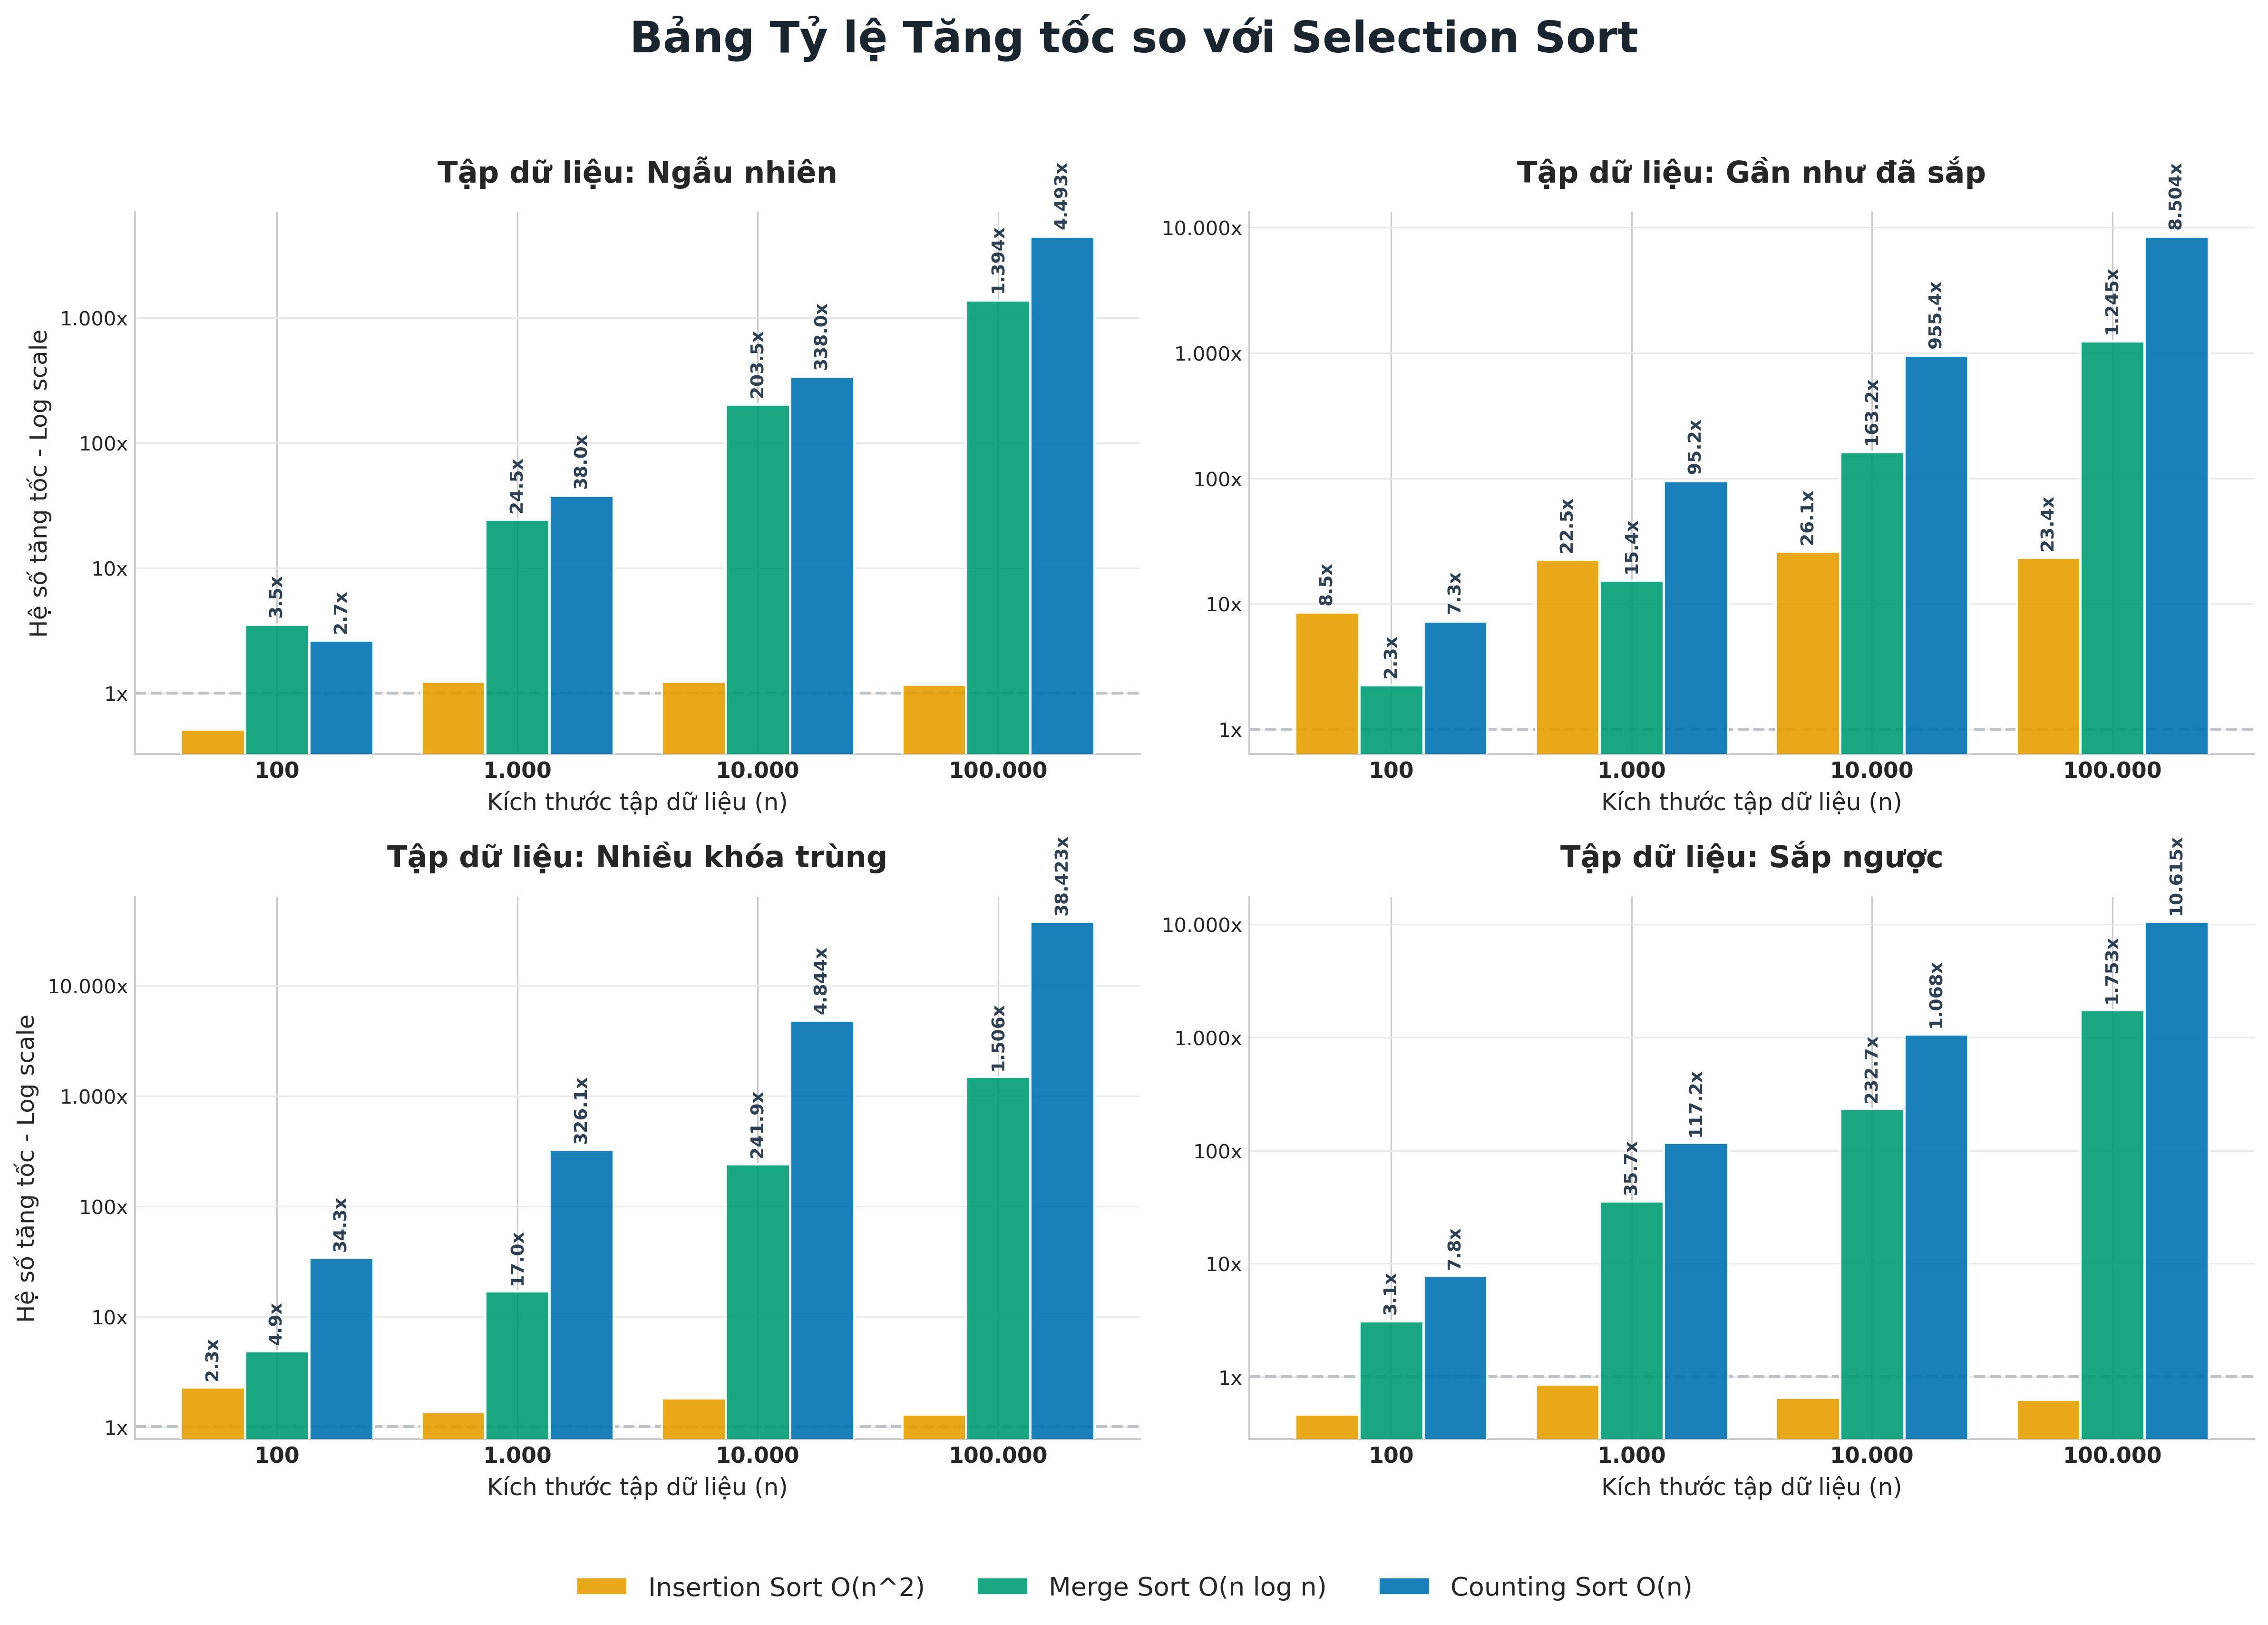

In [6]:
plot_algorithm_speedup_grid(all_algo_results, sizes, datasets, baseline_algo_name="Selection Sort O(n^2)")

## Đánh giá Tỷ lệ Tăng tốc qua hệ quy chiếu Selection Sort
Biểu đồ Tỷ lệ Tăng tốc sử dụng thuật toán Selection Sort làm đường cơ sở (mốc 1x) kết hợp thang đo logarit để làm nổi bật sự chênh lệch hiệu năng giữa các lớp độ phức tạp tại kích thước mảng n = 100.000:
- **Nhóm O(n) (Counting Sort):** Thể hiện khả năng tăng tốc đột phá. Thuật toán đạt đỉnh điểm tối ưu trên tập dữ liệu nhiều khóa trùng với tốc độ nhanh gấp 38.423 lần so với hệ quy chiếu. Ngay cả ở kịch bản thấp nhất là tập dữ liệu ngẫu nhiên, Counting Sort vẫn duy trì mức tăng tốc cực cao lên đến 4.493 lần.
  
- **Nhóm O(n log n) (Merge Sort):** Chứng minh tính ổn định tuyệt đối của phương pháp chia để trị. Hệ số tăng tốc của Merge Sort luôn duy trì ở mức hàng ngàn lần và dao động trong một biên độ rất hẹp qua mọi phân bố: từ 1.245 lần tại mảng gần như đã sắp đến 1.753 lần tại mảng sắp ngược.
  
- **Nhóm O(n²) (Insertion Sort):** Phơi bày sự suy biến và tính nhạy cảm cực đoan với dữ liệu đầu vào. Thuật toán chỉ tận dụng được mảng gần như đã sắp để đạt mức tăng tốc 23.4 lần. Trên các phân bố còn lại, hiệu năng của Insertion Sort chỉ bám sát đường cơ sở 1x và thậm chí chìm hẳn xuống dưới mốc 1x tại tập dữ liệu sắp ngược, khẳng định tốc độ xử lý còn chậm hơn cả thuật toán Selection Sort.

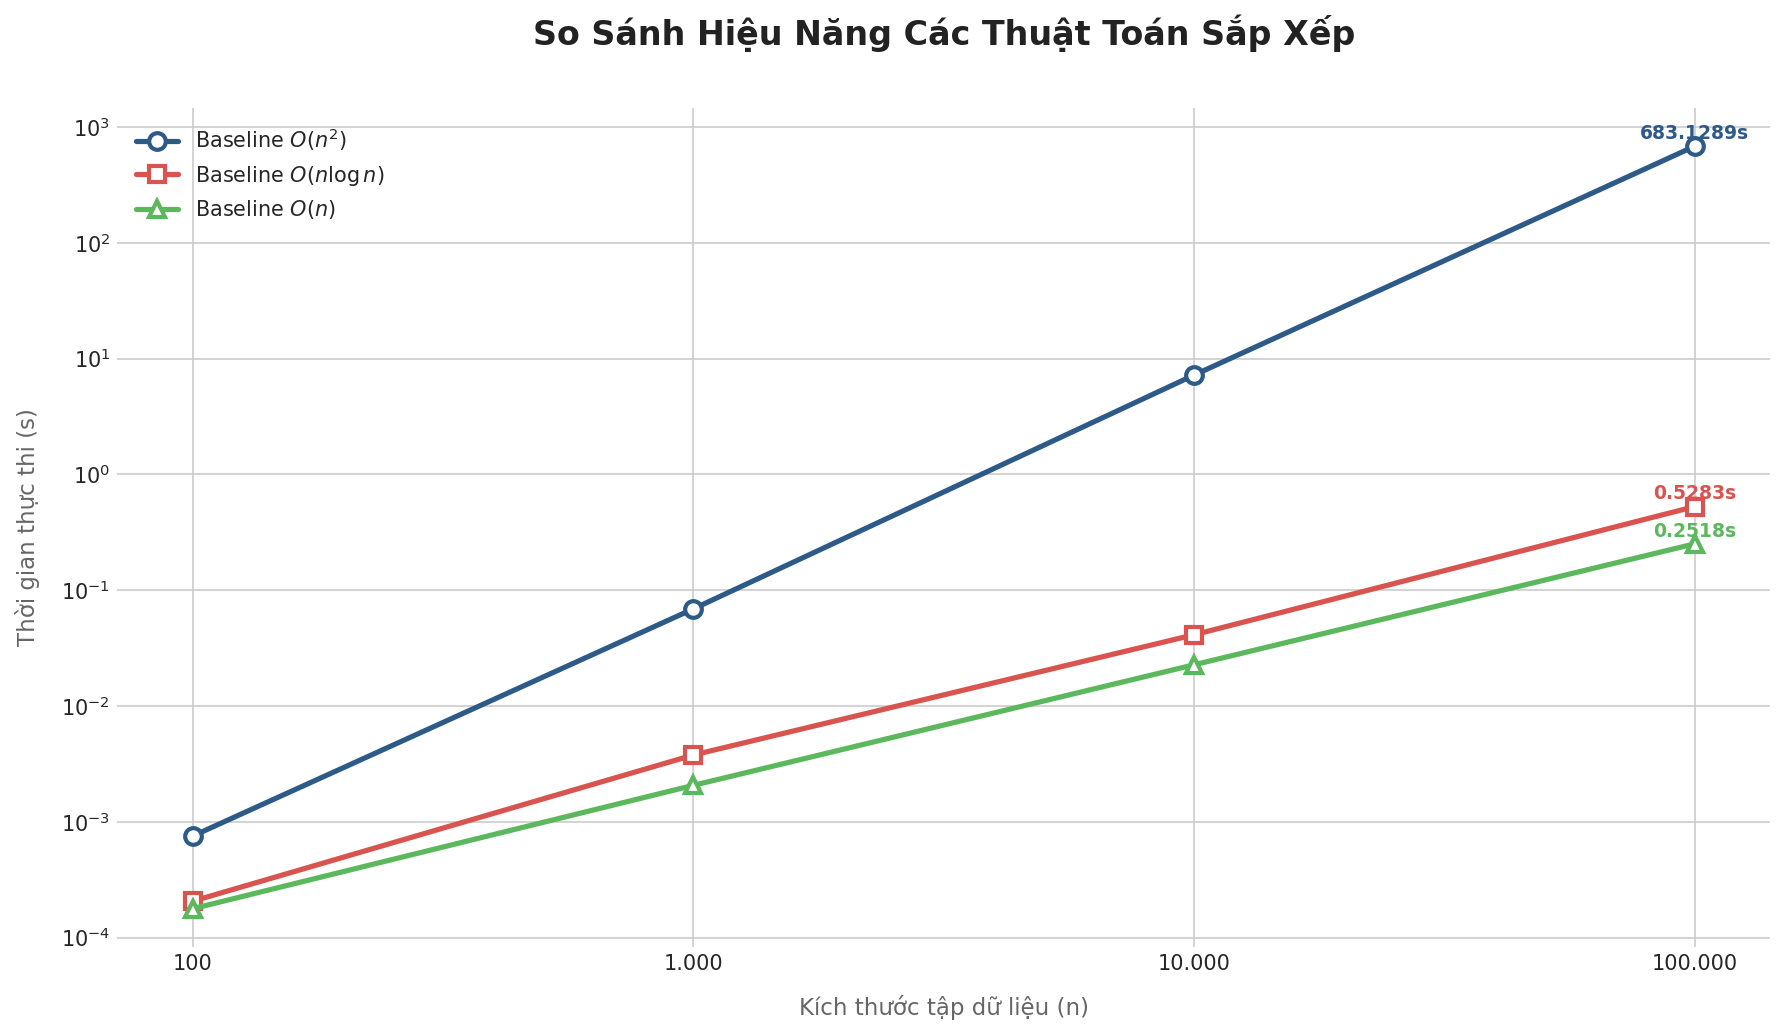

In [7]:
sizes = [100, 1000, 10000, 100000]
folder_path = '../results'
sizes, results_data = load_data_from_folder(folder_path)
plot_multiple_baselines(sizes, results_data, title="So Sánh Hiệu Năng Các Thuật Toán Sắp Xếp")

## Đánh giá Tốc độ Tăng trưởng Thời gian Thực thi theo Lớp Độ phức tạp
Biểu đồ so sánh đường xu hướng trên thang đo logarit kép (log-log scale) phản ánh trực quan sự phân hóa về tốc độ tăng trưởng của ba lớp độ phức tạp thuật toán khi kích thước dữ liệu (n) mở rộng:
- **Lớp độ phức tạp O(n²):** Thể hiện độ dốc lớn nhất, minh chứng cho sự bùng nổ về thời gian xử lý khi dữ liệu tăng dần. Tại mốc n = 100.000, thời gian thực thi vọt lên tới 683.1289 giây, khẳng định sự kém hiệu quả và rủi ro thắt nút cổ chai của lớp thuật toán này khi phải đối mặt với dữ liệu quy mô lớn.

- **Lớp độ phức tạp O(n log n):** Duy trì đường xu hướng tăng trưởng ổn định và thoải hơn đáng kể. Tại mức tải trọng tối đa, thời gian hoàn thành chỉ tốn 0.5283 giây, chứng minh đây là ngưỡng hiệu năng tiêu chuẩn và tối ưu cho các thuật toán sắp xếp dựa trên phép so sánh.

- **Lớp độ phức tạp O(n):** Đường biểu diễn nằm ở vị trí thấp nhất đồ thị, phản ánh tốc độ tăng trưởng tiệm cận tuyến tính. Với thời gian thực thi chỉ 0.2518 giây tại n = 100.000, nhóm thuật toán này thể hiện sức mạnh xử lý vượt trội và là giải pháp lý tưởng nhất khi không bị giới hạn bởi các thao tác so sánh phần tử trực tiếp.